# Дослідницький аналіз даних (Exploratory Data Analysis)

## Мета

Виконати дослідницький аналіз набору даних, дослідити розподіли ознак, взаємозв'язки між ними та визначити потенційні особливості, які можуть вплинути на побудову моделей машинного навчання.

In [22]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import sys
import importlib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [23]:
# ============================================================
# CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# ============================================================
# LOAD PROJECT MODULES
# ============================================================

PROJECT_PATH = "/content/drive/MyDrive/FitnessML_Master"

if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)

importlib.invalidate_caches()

import config
import utils

config = importlib.reload(config)
utils = importlib.reload(utils)

print("✓ Project modules loaded")

✓ Project modules loaded


In [25]:
# ============================================================
# LOAD DATASET
# ============================================================

df = utils.load_dataset()

df["date"] = pd.to_datetime(df["date"])

## Загальна характеристика датасету

На даному етапі виконується первинна статистична оцінка числових ознак набору даних.

Метою є визначення діапазону значень, середніх величин, стандартних відхилень та виявлення потенційних аномалій, які можуть вплинути на подальше моделювання.

In [6]:
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
user_id,365000.0,499.5,0.0,249.75,499.5,749.25,999.0,288.675386
age,365000.0,48.772,18.0,33.0,49.0,64.0,79.0,17.792832
date,365000,2025-03-07 00:00:00.000000512,2024-09-06 00:00:00,2024-12-06 00:00:00,2025-03-07 00:00:00,2025-06-06 00:00:00,2025-09-05 00:00:00,NaN
steps,365000.0,8499.532058,5723.0,7248.0,8497.0,9750.0,11330.0,1446.826636
heart_rate_avg,365000.0,64.979414,13.801607,57.390843,64.997519,72.550623,113.325619,11.246659
sleep_hours,365000.0,7.003109,3.0,5.990209,7.000849,8.015041,12.0,1.495827
calories_burned,365000.0,1999.942722,505.956221,1797.603287,1999.980702,2201.965489,3408.341803,300.05845
exercise_minutes,365000.0,30.054553,0.000025,8.600785,20.784057,41.66498,487.105147,30.145841
stress_level,365000.0,5.50197,1.0,3.0,6.0,8.0,10.0,2.872646
weight_kg,365000.0,70.011188,4.32727,59.90027,69.995579,80.138985,138.765278,15.005358


## Аналіз розподілу ознак

Гістограми дозволяють оцінити форму розподілу числових характеристик, визначити наявність асиметрії, мультимодальності та потенційних викидів.

Отримані результати використовуються для вибору методів нормалізації та подальшої підготовки даних.

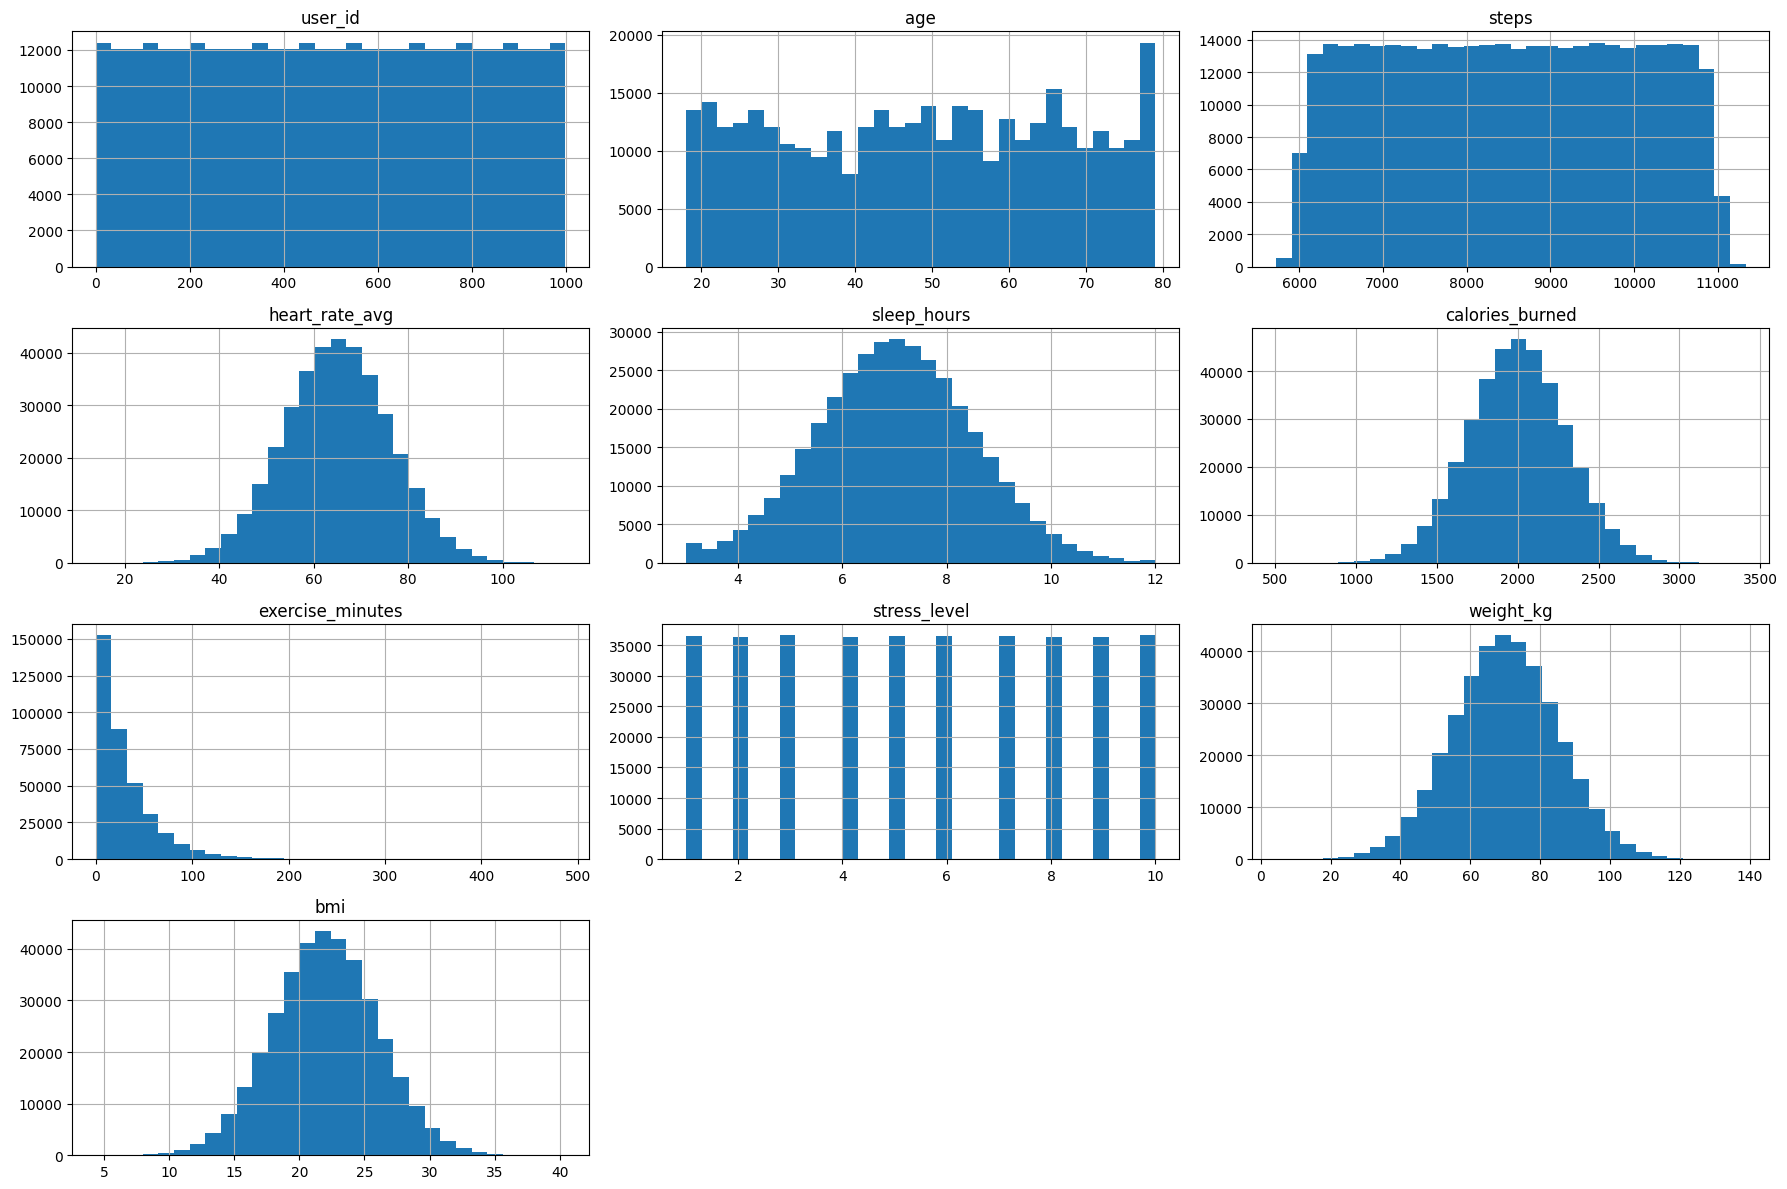

In [26]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()
plt.show()

## Аналіз викидів

Діаграми типу BoxPlot використовуються для візуального визначення можливих аномальних значень.

Наявність значної кількості викидів може вплинути на точність моделей машинного навчання та вимагати додаткової обробки.

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/02_boxplots.png


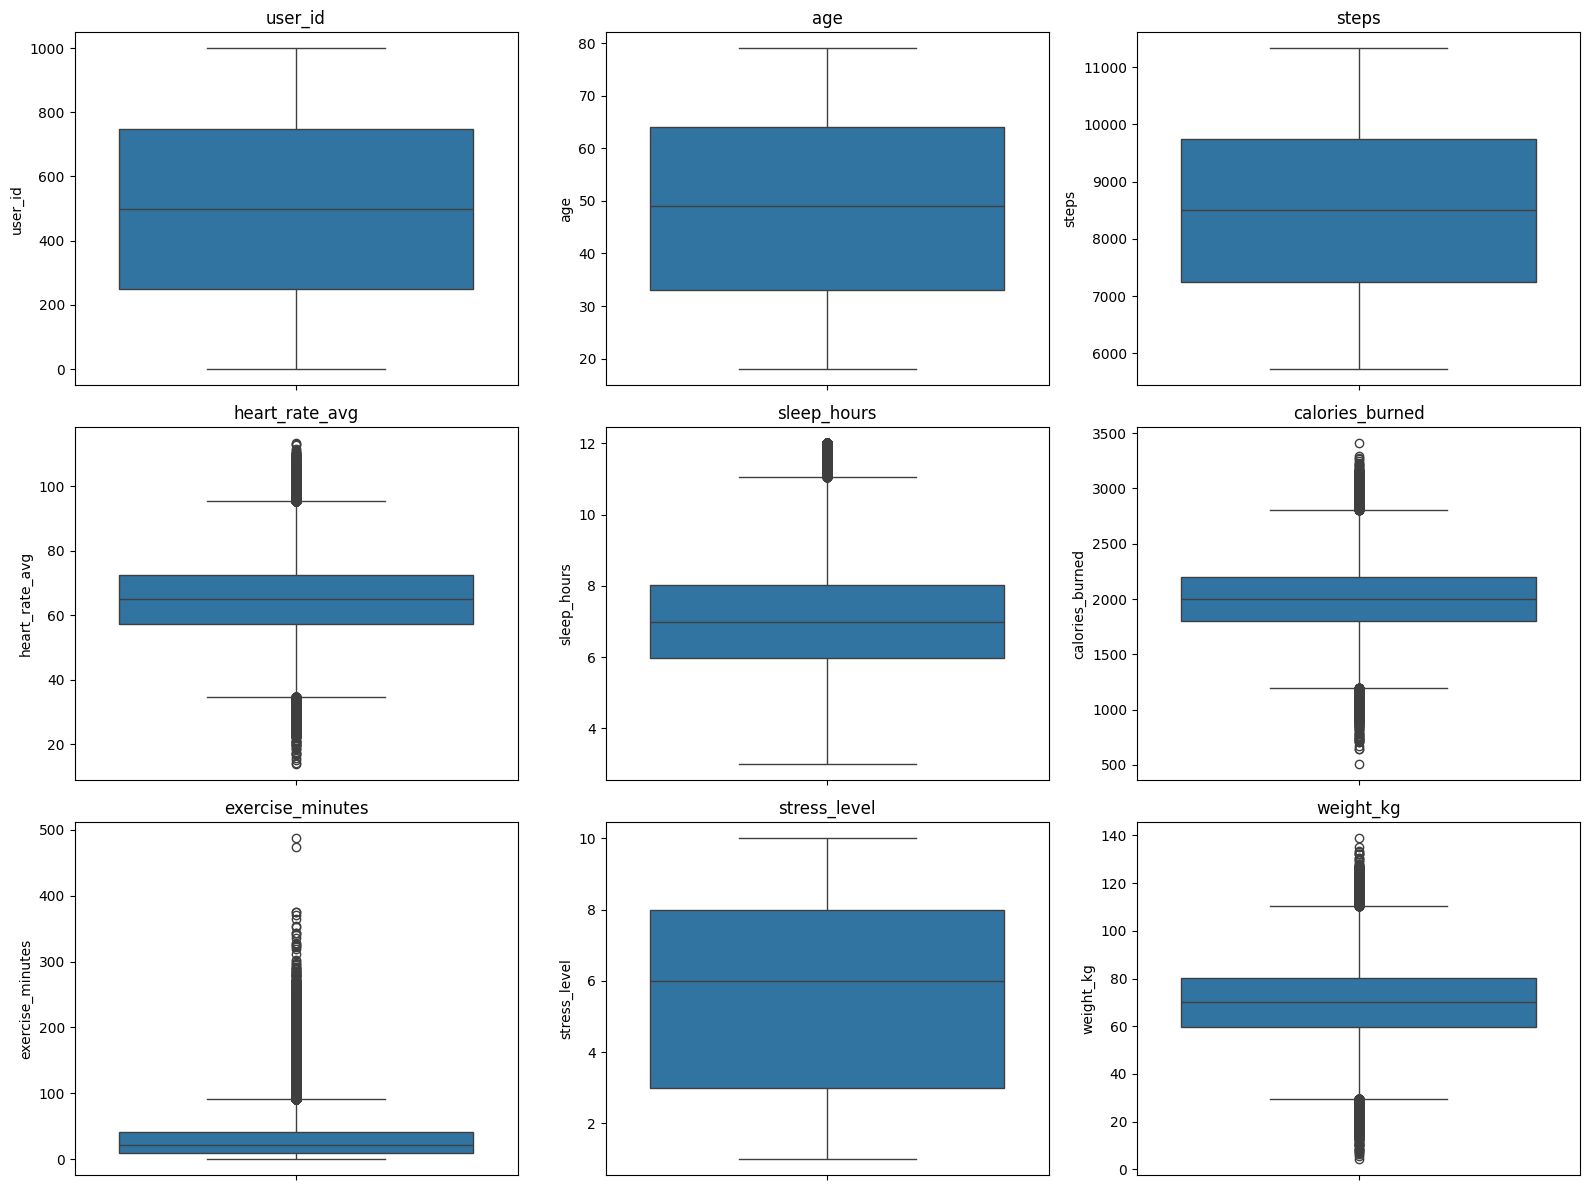

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, column in zip(axes.flat, numeric_columns):

    sns.boxplot(
        y=df[column],
        ax=ax
    )

    ax.set_title(column)

plt.tight_layout()

utils.save_figure(fig, "02_boxplots.png")

In [9]:
gender = df["gender"].value_counts()

display(gender)

,count
gender,
F,186515
M,178485


✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/02_gender_distribution.png


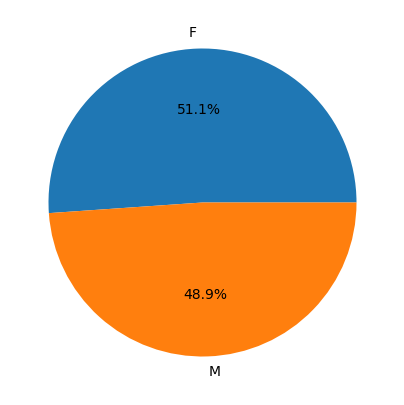

In [10]:
fig = plt.figure(figsize=(5,5))

gender.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

utils.save_figure(fig, "02_gender_distribution.png")

## Кореляційний аналіз

Кореляційна матриця використовується для визначення сили лінійного взаємозв'язку між числовими ознаками.

Результати дозволяють виявити мультиколінеарність та визначити найбільш інформативні характеристики для подальшого моделювання.

In [11]:
corr = df[numeric_columns].corr()

display(corr.round(2))

,user_id,age,steps,heart_rate_avg,sleep_hours,calories_burned,exercise_minutes,stress_level,weight_kg,bmi
user_id,1.00,-0.07,0.0,0.02,0.0,-0.0,-0.0,0.0,0.0,0.0
age,-0.07,1.00,0.0,-0.16,-0.0,-0.0,0.0,-0.0,-0.0,0.0
steps,0.00,0.00,1.0,0.00,-0.0,0.0,0.0,-0.0,0.0,-0.0
heart_rate_avg,0.02,-0.16,0.0,1.00,-0.0,0.0,0.0,0.0,-0.0,0.0
sleep_hours,0.00,-0.00,-0.0,-0.00,1.0,-0.0,0.0,-0.0,-0.0,-0.0
calories_burned,-0.00,-0.00,0.0,0.00,-0.0,1.0,0.0,-0.0,0.0,-0.0
exercise_minutes,-0.00,0.00,0.0,0.00,0.0,0.0,1.0,0.0,0.0,-0.0
stress_level,0.00,-0.00,-0.0,0.00,-0.0,-0.0,0.0,1.0,0.0,-0.0
weight_kg,0.00,-0.00,0.0,-0.00,-0.0,0.0,0.0,0.0,1.0,0.0
bmi,0.00,0.00,-0.0,0.00,-0.0,-0.0,-0.0,-0.0,0.0,1.0


✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/02_correlation_matrix.png


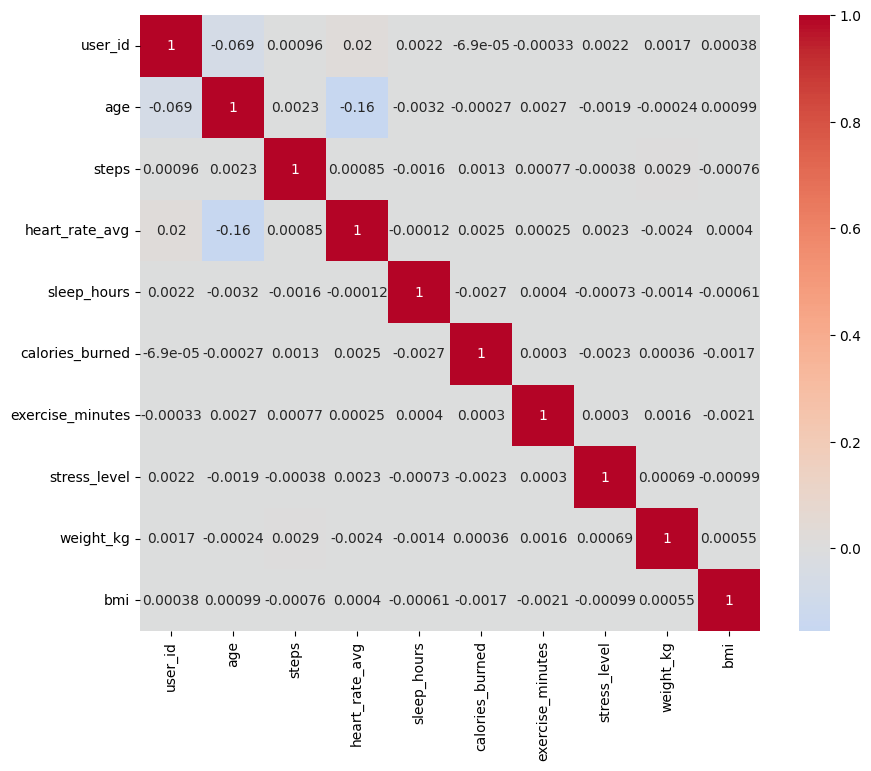

In [12]:
fig = plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

utils.save_figure(fig, "02_correlation_matrix.png")

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/02_exercise_calories.png


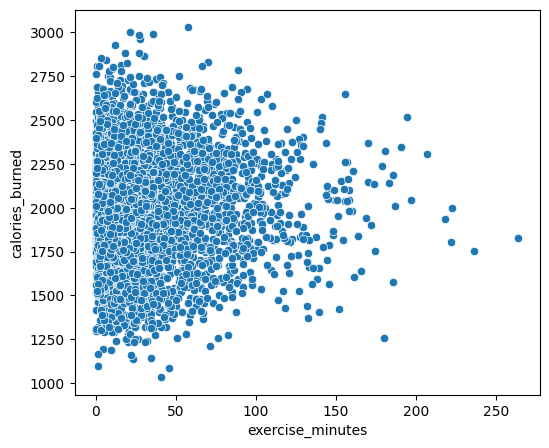

In [13]:
fig = plt.figure(figsize=(6,5))

sns.scatterplot(
    data=df.sample(5000, random_state=config.RANDOM_STATE),
    x="exercise_minutes",
    y="calories_burned"
)

utils.save_figure(fig, "02_exercise_calories.png")

In [15]:
user = df["user_id"].sample(
    1,
    random_state=config.RANDOM_STATE
).iloc[0]

user_df = df[df["user_id"] == user]

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/02_weight_timeseries.png


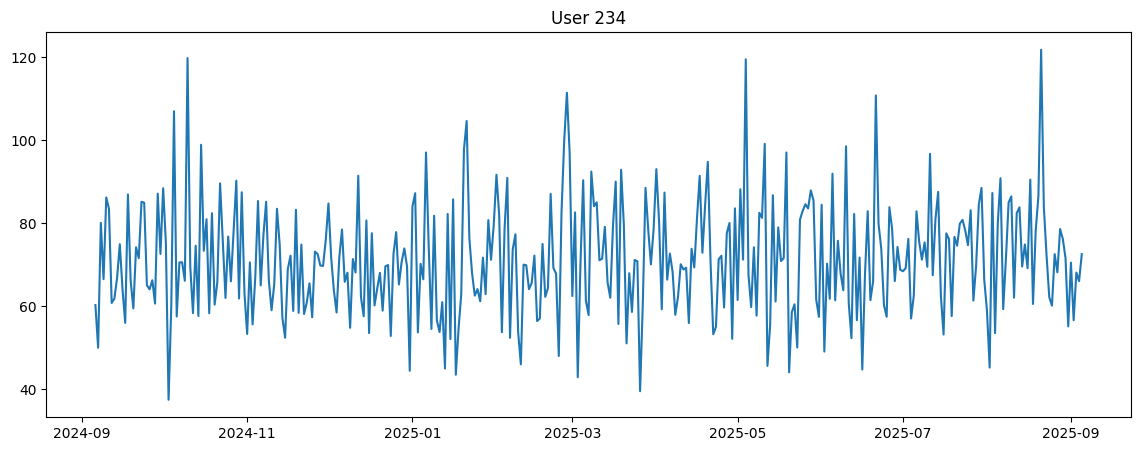

In [21]:
fig = plt.figure(figsize=(14,5))

plt.plot(
    user_df["date"],
    user_df["weight_kg"]
)

plt.title(f"User {user}")

utils.save_figure(fig, "02_weight_timeseries.png")

In [17]:
utils.save_table(
    corr,
    "02_correlation_matrix.csv"
)

utils.save_table(
    gender.to_frame(),
    "02_gender_distribution.csv"
)

✓ Table saved -> /content/drive/MyDrive/FitnessML_Master/tables/02_correlation_matrix.csv
✓ Table saved -> /content/drive/MyDrive/FitnessML_Master/tables/02_gender_distribution.csv


In [19]:
report = f"""
# Exploratory Data Analysis

Numeric features:
{len(numeric_columns)}

Categorical features:
{len(df.select_dtypes(exclude=np.number).columns)}

Strongest positive correlation:

TODO

Strongest negative correlation:

TODO

EDA completed successfully.
"""

utils.save_report(
    report,
    "02_eda.md"
)

✓ Report saved -> /content/drive/MyDrive/FitnessML_Master/reports/02_eda.md


In [20]:
print("="*60)
print("EDA COMPLETED")
print("="*60)

EDA COMPLETED
